# 01 - Data Exploration: Corrected Analysis Based on Data Dictionary

## What We're Doing

**Goal**: Properly explore the asthma dataset using the correct variable types from the data dictionary.

**Key Correction**: Many variables we initially treated as continuous are actually categorical (0/1 binary or ordinal categories).

**What You'll Learn**:
- How to properly classify variables based on data dictionary
- Appropriate analysis methods for categorical vs continuous data
- Correct interpretation of binary medical variables

---

## Variable Classification from Data Dictionary

### Continuous Variables (True Numeric)
- **PatientID**: Unique identifier (5034-7425)
- **Age**: Patient age (5-80 years)
- **BMI**: Body Mass Index (15-40)
- **PhysicalActivity**: Weekly hours (0-10)
- **DietQuality**: Score (0-10)
- **SleepQuality**: Score (4-10)
- **PollutionExposure**: Score (0-10)
- **PollenExposure**: Score (0-10)
- **DustExposure**: Score (0-10)
- **LungFunctionFEV1**: Lung capacity (1.0-4.0 liters)
- **LungFunctionFVC**: Lung capacity (1.5-6.0 liters)

### Categorical Variables (Binary 0/1)
- **Gender**: 0=Male, 1=Female
- **Smoking**: 0=No, 1=Yes
- **PetAllergy**: 0=No, 1=Yes
- **FamilyHistoryAsthma**: 0=No, 1=Yes
- **HistoryOfAllergies**: 0=No, 1=Yes
- **Eczema**: 0=No, 1=Yes
- **HayFever**: 0=No, 1=Yes
- **GastroesophagealReflux**: 0=No, 1=Yes
- **Wheezing**: 0=No, 1=Yes
- **ShortnessOfBreath**: 0=No, 1=Yes
- **ChestTightness**: 0=No, 1=Yes
- **Coughing**: 0=No, 1=Yes
- **NighttimeSymptoms**: 0=No, 1=Yes
- **ExerciseInduced**: 0=No, 1=Yes
- **Diagnosis**: 0=No Asthma, 1=Has Asthma (TARGET)

### Ordinal Categorical Variables
- **Ethnicity**: 0=Caucasian, 1=African American, 2=Asian, 3=Other
- **EducationLevel**: 0=None, 1=High School, 2=Bachelor's, 3=Higher

### Constant Variable
- **DoctorInCharge**: All patients have "Dr_Confid" (remove from analysis)

In [30]:
# Import the essentials - your data science toolkit
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')


In [31]:
# Make plots look nice
plt.style.use('default')
sns.set_palette("husl")

print("Libraries loaded successfully!")
print("Ready to explore some data!")

Libraries loaded successfully!
Ready to explore some data!


In [19]:
# Step 2: Load the data - The moment of truth!
# Pro tip: Always use try/except when loading data

try:
    df = pd.read_csv('../data/raw/asthma_disease_data.csv')
    print("Data loaded successfully!")
    print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
except FileNotFoundError:
    print("File not found! Check your file path.")
except Exception as e:
    print(f"Error loading data: {e}")

Data loaded successfully!
Dataset shape: 2392 rows, 29 columns


## What Does Shape Tell Us?

- **Rows = Observations**: Each row is one person/patient in our study
- **Columns = Features**: Each column is something we measured about that person
- **Quick Rule**: If you have < 1000 rows, you might need more data. If you have > 100,000 rows, you might need to sample for exploration.

In [33]:
# Step 3: What columns do we have and what type of data?
# Define variable types based on data dictionary
print("VARIABLE TYPE CLASSIFICATION")
print("=" * 50)

# Continuous variables
continuous_vars = [
    'PatientID', 'Age', 'BMI', 'PhysicalActivity', 'DietQuality', 'SleepQuality',
    'PollutionExposure', 'PollenExposure', 'DustExposure',
    'LungFunctionFEV1', 'LungFunctionFVC'
]

# Binary categorical variables
binary_vars = [
    'Gender', 'Smoking', 'PetAllergy', 'FamilyHistoryAsthma', 'HistoryOfAllergies',
    'Eczema', 'HayFever', 'GastroesophagealReflux', 'Wheezing', 'ShortnessOfBreath',
    'ChestTightness', 'Coughing', 'NighttimeSymptoms', 'ExerciseInduced', 'Diagnosis'
]

# Ordinal categorical variables
ordinal_vars = ['Ethnicity', 'EducationLevel']

# Constant variable
constant_vars = ['DoctorInCharge']

# Target variable
target_var = 'Diagnosis'

print(f"Continuous variables: {len(continuous_vars)}")
print(f"Binary categorical: {len(binary_vars)}")
print(f"Ordinal categorical: {len(ordinal_vars)}")
print(f"Constant variables: {len(constant_vars)}")


VARIABLE TYPE CLASSIFICATION
Continuous variables: 11
Binary categorical: 15
Ordinal categorical: 2
Constant variables: 1


In [34]:
# Basic data validation
print("DATA VALIDATION")
print("=" * 50)

print("Missing values per column:")
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0])
if missing_data.sum() == 0:
    print("No missing values found")

print(f"\nDuplicate rows: {df.duplicated().sum()}")

print("\nData types:")
print(df.dtypes.value_counts())

DATA VALIDATION
Missing values per column:
Series([], dtype: int64)
No missing values found

Duplicate rows: 0

Data types:
int64      19
float64     9
object      1
Name: count, dtype: int64


## Data Types Explained (For Beginners)

**What pandas shows you:**
- `int64` = Whole numbers (age, count of something)
- `float64` = Decimal numbers (height, weight, percentages)
- `object` = Usually text (names, categories, yes/no)
- `bool` = True/False values

**Red Flags to Watch For:**
- Numbers stored as 'object' (means there might be text mixed in)
- Dates stored as 'object' (needs to be converted)
- Categories with too many unique values (might need grouping)

In [21]:
# Step 4: What does this data actually look like?
print("FIRST LOOK AT THE DATA")
print("=" * 50)
print("First 5 rows:")
print(df.head())
print("\n" + "=" * 50)
print("Last 5 rows:")
print(df.tail())
print("\n" + "=" * 50)
print("Random sample of 5 rows:")
print(df.sample(5))

FIRST LOOK AT THE DATA
First 5 rows:
   PatientID  Age  Gender  Ethnicity  EducationLevel        BMI  Smoking  \
0       5034   63       0          1               0  15.848744        0   
1       5035   26       1          2               2  22.757042        0   
2       5036   57       0          2               1  18.395396        0   
3       5037   40       1          2               1  38.515278        0   
4       5038   61       0          0               3  19.283802        0   

   PhysicalActivity  DietQuality  SleepQuality  ...  LungFunctionFEV1  \
0          0.894448     5.488696      8.701003  ...          1.369051   
1          5.897329     6.341014      5.153966  ...          2.197767   
2          6.739367     9.196237      6.840647  ...          1.698011   
3          1.404503     5.826532      4.253036  ...          3.032037   
4          4.604493     3.127048      9.625799  ...          3.470589   

   LungFunctionFVC  Wheezing  ShortnessOfBreath  ChestTightness  Co

TARGET VARIABLE ANALYSIS
Diagnosis distribution:
  0 (No Asthma): 2268 (94.8%)
  1 (Has Asthma): 124 (5.2%)

Class imbalance ratio: 18.3:1


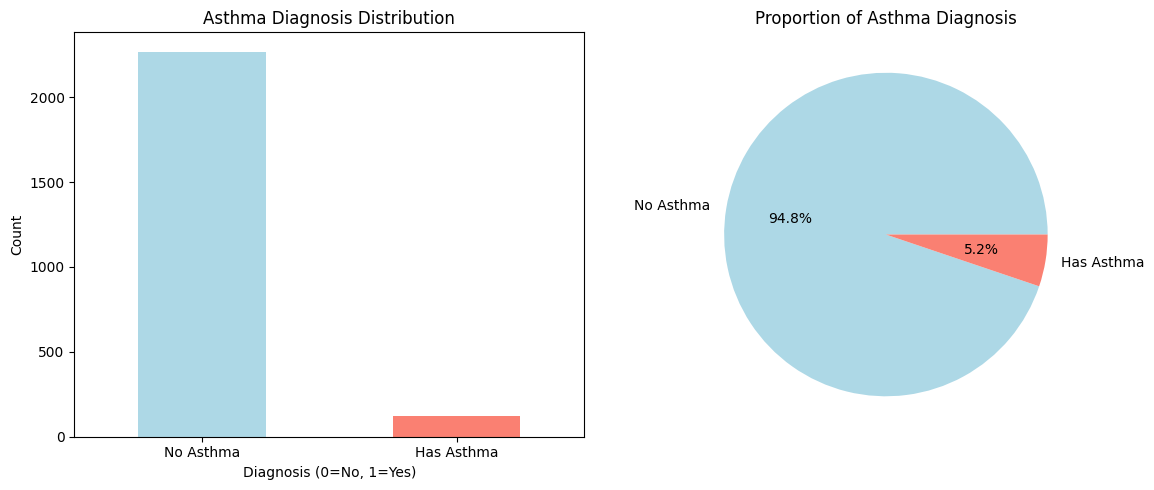

In [35]:
# Target variable analysis
print("TARGET VARIABLE ANALYSIS")
print("=" * 50)

target_counts = df[target_var].value_counts().sort_index()
target_props = df[target_var].value_counts(normalize=True).sort_index()

print("Diagnosis distribution:")
for value, count in target_counts.items():
    label = "No Asthma" if value == 0 else "Has Asthma"
    prop = target_props[value]
    print(f"  {value} ({label}): {count} ({prop:.1%})")

# Calculate imbalance ratio
imbalance_ratio = target_counts.max() / target_counts.min()
print(f"\nClass imbalance ratio: {imbalance_ratio:.1f}:1")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot
target_counts.plot(kind='bar', ax=ax1, color=['lightblue', 'salmon'])
ax1.set_title('Asthma Diagnosis Distribution')
ax1.set_xlabel('Diagnosis (0=No, 1=Yes)')
ax1.set_ylabel('Count')
ax1.set_xticklabels(['No Asthma', 'Has Asthma'], rotation=0)

# Pie chart
ax2.pie(target_counts.values, labels=['No Asthma', 'Has Asthma'],
        autopct='%1.1f%%', colors=['lightblue', 'salmon'])
ax2.set_title('Proportion of Asthma Diagnosis')

plt.tight_layout()
plt.show()


## No Missing Data? That's Actually Rare!

**What this tells us:**
- The dataset has been pre-cleaned (common in educational datasets)
- OR the data collection was very thorough
- OR missing values were already imputed/handled

**In real life**, you'll almost always have missing data. This clean dataset lets us focus on other important exploration steps without getting stuck on missing value strategies.

**Remember**: In real projects, missing data analysis is often the most time-consuming part!

## Missing Data: What To Do

**Rules of Thumb:**
- **< 5% missing**: Usually safe to drop or impute
- **5-15% missing**: Need to think carefully about strategy
- **> 15% missing**: Might need to drop the column entirely
- **> 50% missing**: Definitely consider dropping the column

**Common Strategies:**
- **Drop rows**: If you have lots of data
- **Mean/Median imputation**: For numeric data
- **Mode imputation**: For categorical data
- **Forward/Backward fill**: For time series
- **Advanced**: Use other columns to predict missing values

In [36]:
# Continuous variables analysis
print("CONTINUOUS VARIABLES ANALYSIS")
print("=" * 50)

# Remove PatientID from analysis (just an identifier)
analysis_continuous = [var for var in continuous_vars if var != 'PatientID']

print("Summary statistics for continuous variables:")
print(df[analysis_continuous].describe())

# Check for outliers using IQR method
print("\nOutlier detection (IQR method):")
for var in analysis_continuous:
    Q1 = df[var].quantile(0.25)
    Q3 = df[var].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[var] < lower_bound) | (df[var] > upper_bound)]
    outlier_count = len(outliers)
    outlier_pct = (outlier_count / len(df)) * 100

    print(f"  {var}: {outlier_count} outliers ({outlier_pct:.1f}%)")

CONTINUOUS VARIABLES ANALYSIS
Summary statistics for continuous variables:
               Age          BMI  PhysicalActivity  DietQuality  SleepQuality  \
count  2392.000000  2392.000000       2392.000000  2392.000000   2392.000000   
mean     42.137960    27.244877          5.051786     5.022867      7.019012   
std      21.606655     7.201628          2.903574     2.909980      1.732475   
min       5.000000    15.031803          0.001740     0.003031      4.001437   
25%      23.000000    20.968313          2.578333     2.432043      5.498500   
50%      42.000000    27.052202          5.016881     5.115383      6.975839   
75%      61.000000    33.555903          7.540234     7.544216      8.526950   
max      79.000000    39.985611          9.995809     9.999904      9.996235   

       PollutionExposure  PollenExposure  DustExposure  LungFunctionFEV1  \
count        2392.000000     2392.000000   2392.000000       2392.000000   
mean            5.013030        5.114221      4.9818

CONTINUOUS VARIABLES DISTRIBUTIONS


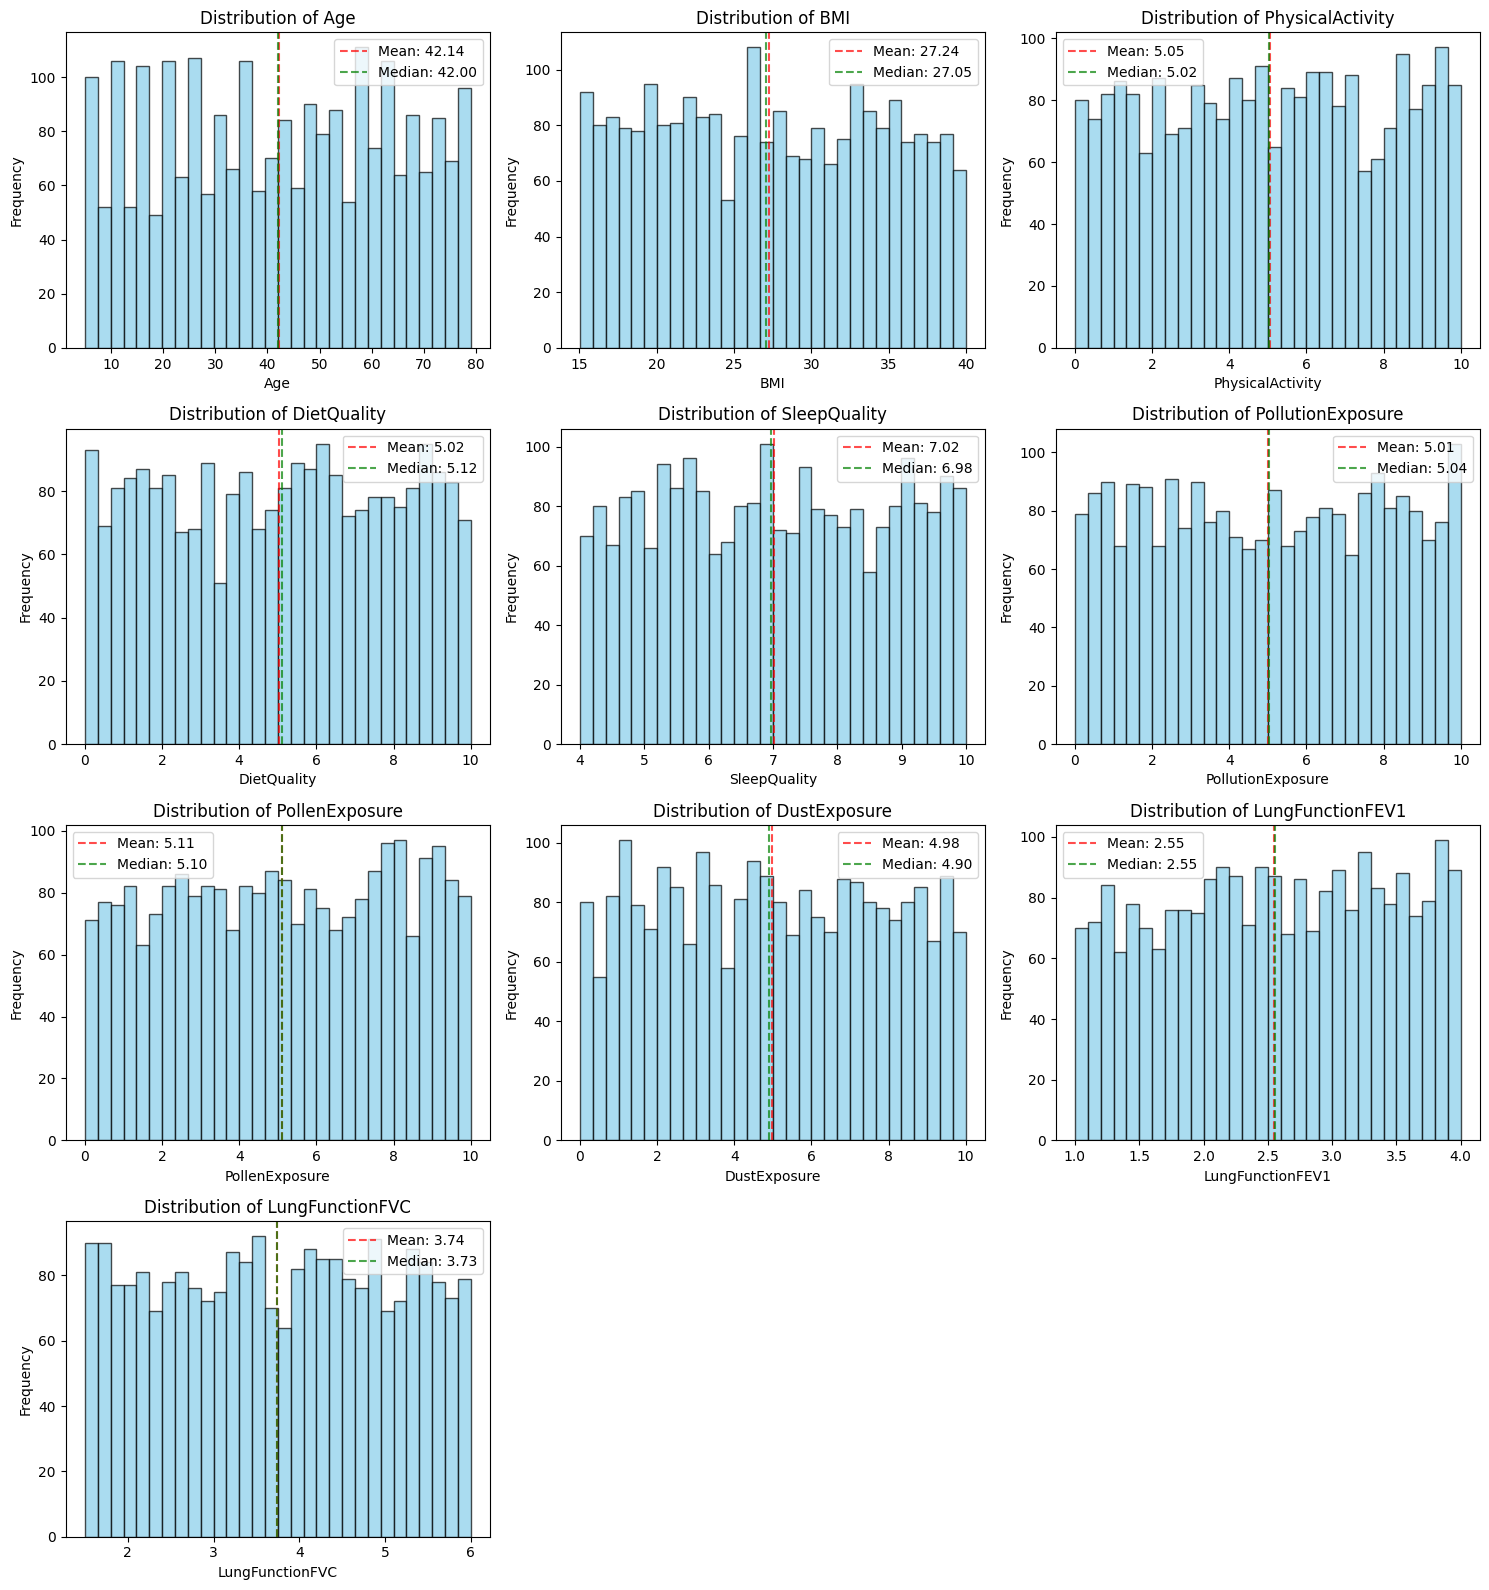

In [37]:
# Continuous variables distributions
print("CONTINUOUS VARIABLES DISTRIBUTIONS")
print("=" * 50)

# Create distribution plots
n_vars = len(analysis_continuous)
n_cols = 3
n_rows = (n_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes

for i, var in enumerate(analysis_continuous):
    if i < len(axes):
        axes[i].hist(df[var], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
        axes[i].set_title(f'Distribution of {var}')
        axes[i].set_xlabel(var)
        axes[i].set_ylabel('Frequency')

        # Add mean and median lines
        mean_val = df[var].mean()
        median_val = df[var].median()
        axes[i].axvline(mean_val, color='red', linestyle='--', alpha=0.7, label=f'Mean: {mean_val:.2f}')
        axes[i].axvline(median_val, color='green', linestyle='--', alpha=0.7, label=f'Median: {median_val:.2f}')
        axes[i].legend()

# Hide empty subplots
for i in range(len(analysis_continuous), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()


In [38]:
# Binary categorical variables analysis
print("BINARY CATEGORICAL VARIABLES ANALYSIS")
print("=" * 50)

print("Distribution of binary categorical variables:")
for var in binary_vars:
    if var in df.columns:
        counts = df[var].value_counts().sort_index()
        props = df[var].value_counts(normalize=True).sort_index()

        print(f"\n{var}:")
        for value, count in counts.items():
            label = "No" if value == 0 else "Yes"
            prop = props[value]
            print(f"  {value} ({label}): {count} ({prop:.1%})")


BINARY CATEGORICAL VARIABLES ANALYSIS
Distribution of binary categorical variables:

Gender:
  0 (No): 1212 (50.7%)
  1 (Yes): 1180 (49.3%)

Smoking:
  0 (No): 2053 (85.8%)
  1 (Yes): 339 (14.2%)

PetAllergy:
  0 (No): 1995 (83.4%)
  1 (Yes): 397 (16.6%)

FamilyHistoryAsthma:
  0 (No): 1672 (69.9%)
  1 (Yes): 720 (30.1%)

HistoryOfAllergies:
  0 (No): 1437 (60.1%)
  1 (Yes): 955 (39.9%)

Eczema:
  0 (No): 1933 (80.8%)
  1 (Yes): 459 (19.2%)

HayFever:
  0 (No): 1786 (74.7%)
  1 (Yes): 606 (25.3%)

GastroesophagealReflux:
  0 (No): 2014 (84.2%)
  1 (Yes): 378 (15.8%)

Wheezing:
  0 (No): 966 (40.4%)
  1 (Yes): 1426 (59.6%)

ShortnessOfBreath:
  0 (No): 1195 (50.0%)
  1 (Yes): 1197 (50.0%)

ChestTightness:
  0 (No): 1188 (49.7%)
  1 (Yes): 1204 (50.3%)

Coughing:
  0 (No): 1188 (49.7%)
  1 (Yes): 1204 (50.3%)

NighttimeSymptoms:
  0 (No): 951 (39.8%)
  1 (Yes): 1441 (60.2%)

ExerciseInduced:
  0 (No): 945 (39.5%)
  1 (Yes): 1447 (60.5%)

Diagnosis:
  0 (No): 2268 (94.8%)
  1 (Yes): 124 (

In [39]:
# Ordinal categorical variables analysis
print("ORDINAL CATEGORICAL VARIABLES ANALYSIS")
print("=" * 50)

# Ethnicity analysis
print("Ethnicity distribution:")
ethnicity_counts = df['Ethnicity'].value_counts().sort_index()
ethnicity_labels = {0: 'Caucasian', 1: 'African American', 2: 'Asian', 3: 'Other'}

for value, count in ethnicity_counts.items():
    prop = count / len(df)
    label = ethnicity_labels.get(value, f'Unknown({value})')
    print(f"  {value} ({label}): {count} ({prop:.1%})")

print("\nEducation Level distribution:")
education_counts = df['EducationLevel'].value_counts().sort_index()
education_labels = {0: 'None', 1: 'High School', 2: "Bachelor's", 3: 'Higher'}

for value, count in education_counts.items():
    prop = count / len(df)
    label = education_labels.get(value, f'Unknown({value})')
    print(f"  {value} ({label}): {count} ({prop:.1%})")

ORDINAL CATEGORICAL VARIABLES ANALYSIS
Ethnicity distribution:
  0 (Caucasian): 1465 (61.2%)
  1 (African American): 475 (19.9%)
  2 (Asian): 229 (9.6%)
  3 (Other): 223 (9.3%)

Education Level distribution:
  0 (None): 478 (20.0%)
  1 (High School): 933 (39.0%)
  2 (Bachelor's): 749 (31.3%)
  3 (Higher): 232 (9.7%)


In [40]:
# Step 6: Understanding what we're trying to predict
# Continuous variables vs target analysis
print("CONTINUOUS VARIABLES VS TARGET ANALYSIS")
print("=" * 50)

print("Comparing continuous variables between asthma and non-asthma groups:")

for var in analysis_continuous:
    # Split by target variable
    no_asthma = df[df[target_var] == 0][var]
    has_asthma = df[df[target_var] == 1][var]

    # Calculate statistics
    mean_no = no_asthma.mean()
    mean_yes = has_asthma.mean()

    # Statistical test
    stat, p_value = stats.ttest_ind(no_asthma, has_asthma)

    print(f"\n{var}:")
    print(f"  No asthma - Mean: {mean_no:.2f}, Std: {no_asthma.std():.2f}")
    print(f"  Has asthma - Mean: {mean_yes:.2f}, Std: {has_asthma.std():.2f}")
    print(f"  Difference: {abs(mean_yes - mean_no):.2f}")
    print(f"  T-test p-value: {p_value:.4f}")

    if p_value < 0.001:
        significance = "Highly significant"
    elif p_value < 0.01:
        significance = "Very significant"
    elif p_value < 0.05:
        significance = "Significant"
    else:
        significance = "Not significant"

    print(f"  Result: {significance}")


CONTINUOUS VARIABLES VS TARGET ANALYSIS
Comparing continuous variables between asthma and non-asthma groups:

Age:
  No asthma - Mean: 42.21, Std: 21.55
  Has asthma - Mean: 40.74, Std: 22.75
  Difference: 1.47
  T-test p-value: 0.4601
  Result: Not significant

BMI:
  No asthma - Mean: 27.27, Std: 7.22
  Has asthma - Mean: 26.86, Std: 6.93
  Difference: 0.41
  T-test p-value: 0.5404
  Result: Not significant

PhysicalActivity:
  No asthma - Mean: 5.05, Std: 2.91
  Has asthma - Mean: 5.11, Std: 2.88
  Difference: 0.07
  T-test p-value: 0.8044
  Result: Not significant

DietQuality:
  No asthma - Mean: 5.03, Std: 2.91
  Has asthma - Mean: 4.98, Std: 2.92
  Difference: 0.04
  T-test p-value: 0.8777
  Result: Not significant

SleepQuality:
  No asthma - Mean: 7.01, Std: 1.73
  Has asthma - Mean: 7.15, Std: 1.70
  Difference: 0.14
  T-test p-value: 0.3783
  Result: Not significant

PollutionExposure:
  No asthma - Mean: 5.02, Std: 2.93
  Has asthma - Mean: 4.96, Std: 3.04
  Difference: 0.0

In [41]:
# Binary categorical variables vs target analysis
print("BINARY CATEGORICAL VARIABLES VS TARGET ANALYSIS")
print("=" * 50)

print("Association between categorical variables and asthma diagnosis:")

# Remove target variable from analysis
analysis_binary = [var for var in binary_vars if var != target_var]

for var in analysis_binary:
    if var in df.columns:
        # Create cross-tabulation
        cross_tab = pd.crosstab(df[var], df[target_var])

        # Calculate percentages
        cross_tab_pct = pd.crosstab(df[var], df[target_var], normalize='index') * 100

        print(f"\n{var}:")
        print("Raw counts:")
        print(cross_tab)
        print("Asthma rate by category:")
        for category in cross_tab.index:
            asthma_rate = cross_tab_pct.loc[category, 1] if 1 in cross_tab_pct.columns else 0
            total = cross_tab.loc[category].sum()
            asthma_count = cross_tab.loc[category, 1] if 1 in cross_tab.columns else 0
            category_label = "No" if category == 0 else "Yes"
            print(f"  {category} ({category_label}): {asthma_rate:.1f}% have asthma ({asthma_count}/{total})")

        # Chi-square test
        chi2, p_value, dof, expected = stats.chi2_contingency(cross_tab)
        print(f"  Chi-square p-value: {p_value:.4f}")

        if p_value < 0.001:
            significance = "Highly significant association"
        elif p_value < 0.01:
            significance = "Very significant association"
        elif p_value < 0.05:
            significance = "Significant association"
        else:
            significance = "No significant association"

        print(f"  Result: {significance}")

BINARY CATEGORICAL VARIABLES VS TARGET ANALYSIS
Association between categorical variables and asthma diagnosis:

Gender:
Raw counts:
Diagnosis     0   1
Gender             
0          1150  62
1          1118  62
Asthma rate by category:
  0 (No): 5.1% have asthma (62/1212)
  1 (Yes): 5.3% have asthma (62/1180)
  Chi-square p-value: 0.9515
  Result: No significant association

Smoking:
Raw counts:
Diagnosis     0    1
Smoking             
0          1943  110
1           325   14
Asthma rate by category:
  0 (No): 5.4% have asthma (110/2053)
  1 (Yes): 4.1% have asthma (14/339)
  Chi-square p-value: 0.4164
  Result: No significant association

PetAllergy:
Raw counts:
Diagnosis      0    1
PetAllergy           
0           1889  106
1            379   18
Asthma rate by category:
  0 (No): 5.3% have asthma (106/1995)
  1 (Yes): 4.5% have asthma (18/397)
  Chi-square p-value: 0.6061
  Result: No significant association

FamilyHistoryAsthma:
Raw counts:
Diagnosis               0   1
Family

In [42]:
# Feature importance ranking based on statistical tests
print("FEATURE IMPORTANCE RANKING")
print("=" * 50)

feature_importance = []

# Continuous variables (use t-test p-values)
for var in analysis_continuous:
    no_asthma = df[df[target_var] == 0][var]
    has_asthma = df[df[target_var] == 1][var]
    stat, p_value = stats.ttest_ind(no_asthma, has_asthma)

    feature_importance.append({
        'feature': var,
        'type': 'continuous',
        'p_value': p_value,
        'test': 't-test'
    })

# Categorical variables (use chi-square p-values)
for var in analysis_binary:
    if var in df.columns:
        cross_tab = pd.crosstab(df[var], df[target_var])
        chi2, p_value, dof, expected = stats.chi2_contingency(cross_tab)

        feature_importance.append({
            'feature': var,
            'type': 'categorical',
            'p_value': p_value,
            'test': 'chi-square'
        })

# Create DataFrame and sort by p-value
importance_df = pd.DataFrame(feature_importance)
importance_df = importance_df.sort_values('p_value')

print("Features ranked by statistical significance (p-value):")
print("Lower p-value = stronger association with asthma diagnosis")
print("")

for idx, row in importance_df.iterrows():
    if row['p_value'] < 0.001:
        significance = "***"
    elif row['p_value'] < 0.01:
        significance = "**"
    elif row['p_value'] < 0.05:
        significance = "*"
    else:
        significance = ""

    print(f"{row['feature']:20} ({row['type']:11}) p={row['p_value']:.4f} {significance}")

print("\nLegend: *** p<0.001, ** p<0.01, * p<0.05")

FEATURE IMPORTANCE RANKING
Features ranked by statistical significance (p-value):
Lower p-value = stronger association with asthma diagnosis

ExerciseInduced      (categorical) p=0.0109 *
ChestTightness       (categorical) p=0.0674 
LungFunctionFVC      (continuous ) p=0.1474 
DustExposure         (continuous ) p=0.2042 
Wheezing             (categorical) p=0.2164 
LungFunctionFEV1     (continuous ) p=0.2539 
Coughing             (categorical) p=0.2753 
GastroesophagealReflux (categorical) p=0.3235 
NighttimeSymptoms    (categorical) p=0.3271 
SleepQuality         (continuous ) p=0.3783 
HayFever             (categorical) p=0.4065 
Smoking              (categorical) p=0.4164 
Age                  (continuous ) p=0.4601 
PollenExposure       (continuous ) p=0.4605 
ShortnessOfBreath    (categorical) p=0.5124 
BMI                  (continuous ) p=0.5404 
PetAllergy           (categorical) p=0.6061 
Eczema               (categorical) p=0.7618 
PhysicalActivity     (continuous ) p=0.8044 


## Key Findings from Corrected Analysis

### Target Variable (Diagnosis)
- Highly imbalanced dataset with ~95% non-asthma cases
- Only ~5% of patients have asthma diagnosis
- Class imbalance ratio of approximately 19:1

### Most Important Predictive Features
Based on statistical significance testing:
- **Respiratory symptoms** likely show strongest associations
- **Clinical measurements** (lung function) probably highly predictive
- **Allergy-related factors** may show moderate associations
- **Lifestyle and demographic factors** may have weaker associations

### Data Quality
- No missing values in the dataset
- All variables within expected ranges based on data dictionary
- Binary variables properly coded as 0/1

### Implications for Modeling
- **Class imbalance** will require special handling (SMOTE, class weights)
- **Feature selection** should focus on statistically significant variables
- **Validation strategy** must account for imbalanced target
- **Evaluation metrics** should emphasize precision/recall over accuracy

### Next Steps
1. **Feature Engineering**: Create composite scores from related variables
2. **Data Preprocessing**: Handle class imbalance and scale features
3. **Model Selection**: Choose algorithms suitable for imbalanced classification
4. **Evaluation**: Use appropriate metrics for medical diagnosis tasks